In [82]:
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchinfo import summary
from torchvision import datasets, transforms
import time
import pandas as pd

In [83]:
# 1. Configuration and Data Loading
BATCH_SIZE = 64

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Grayscale()
])

In [84]:
train_data = datasets.ImageFolder(
    root='./data/train',
    transform=data_transform
)
test_data = datasets.ImageFolder(
    root='./data/test',
    transform=data_transform
)

In [85]:
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=4)
test_loader = DataLoader(dataset=test_data,
                             shuffle=True, num_workers=0)

In [86]:
# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [87]:
# 2. Define the Neural Network Model
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        # 48 48
        self.pool0 = nn.MaxPool2d(kernel_size=1) # 48 48

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3)  # 46 46
        self.pool1 = nn.MaxPool2d(kernel_size=2)  #23 23

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3)  #21 21
        self.pool2 = nn.AvgPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)  #10 10
        self.pool3 = nn.AdaptiveMaxPool2d(output_size=(5, 5))
        # self.pool2 = nn.MaxPool2d(kernel_size=3)

        self.fc3 = nn.Linear(64 * 5 * 5, 7)

    def forward(self, x):
        x = self.pool0(x)

        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        x = self.pool3(x)

        x = x.view(-1, 64 * 5 * 5)
        x = self.fc3(x)
        # Apply log softmax for the final output (often used with NLLLoss, which is part of CrossEntropyLoss)
        return F.log_softmax(x, dim=1)


model = SimpleNN().to(device)

In [88]:
# 3. Define Loss and Optimizer
criterion = nn.NLLLoss()  # Negative Log-Likelihood Loss (suitable for log_softmax output)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [89]:
summary(model)

Layer (type:depth-idx)                   Param #
SimpleNN                                 --
├─MaxPool2d: 1-1                         --
├─Conv2d: 1-2                            160
├─MaxPool2d: 1-3                         --
├─Conv2d: 1-4                            4,640
├─AdaptiveAvgPool2d: 1-5                 --
├─Linear: 1-6                            18,151
Total params: 22,951
Trainable params: 22,951
Non-trainable params: 0

In [90]:
def format_time(seconds):
    """Convert seconds to HH:MM:SS format."""
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    return f"{hours:02d}:{minutes:02d}:{secs:02d}"

In [91]:
# 4. Training Loop
from datetime import datetime
writer = SummaryWriter(f'runs/init_{datetime.now().strftime("%Y_%m_%d-%H_%M_%S")}')
NUM_EPOCHS = 20

train_start = time.time()

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0
    epoch_start = time.time()
    total_batches = len(train_loader)

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 100 == 0:
            elapsed = time.time() - epoch_start
            batches_done = batch_idx + 1
            # Avoid division by zero
            avg_time_per_batch = elapsed / batches_done
            remaining_batches = total_batches - batches_done
            remaining = avg_time_per_batch * remaining_batches

            elapsed_str = format_time(elapsed)
            remaining_str = format_time(max(remaining, 0))

            print(f'Train Epoch: {epoch + 1}/{NUM_EPOCHS} '
                  f'[{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / total_batches:.0f}%)]\t'
                  f'Loss: {loss.item():.6f}\t'
                  f'Elapsed: {elapsed_str}\t'
                  f'Remaining: {remaining_str}')

    avg_train_loss = running_loss / total_batches
    writer.add_scalar('Loss/Train', avg_train_loss, epoch)
    epoch_time = time.time() - epoch_start
    print(f'Epoch {epoch+1} completed in {format_time(epoch_time)}')
    print(f"Avg epoch loss: {avg_train_loss}")

train_time = time.time() - train_start
print(f"Train time: {format_time(train_time)}")

writer.flush()
writer.close()

Train Epoch: 1/20 [0/28709 (0%)]	Loss: 1.937761	Elapsed: 00:00:22	Remaining: 02:47:41
Train Epoch: 1/20 [6400/28709 (22%)]	Loss: 1.759639	Elapsed: 00:00:27	Remaining: 00:01:33
Train Epoch: 1/20 [12800/28709 (45%)]	Loss: 1.636576	Elapsed: 00:00:31	Remaining: 00:00:39
Train Epoch: 1/20 [19200/28709 (67%)]	Loss: 1.699661	Elapsed: 00:00:36	Remaining: 00:00:17
Train Epoch: 1/20 [25600/28709 (89%)]	Loss: 1.716196	Elapsed: 00:00:41	Remaining: 00:00:04
Epoch 1 completed in 00:00:44
Avg epoch loss: 1.722111562578078
Train Epoch: 2/20 [0/28709 (0%)]	Loss: 1.633577	Elapsed: 00:00:22	Remaining: 02:48:01
Train Epoch: 2/20 [6400/28709 (22%)]	Loss: 1.610342	Elapsed: 00:00:27	Remaining: 00:01:34
Train Epoch: 2/20 [12800/28709 (45%)]	Loss: 1.646622	Elapsed: 00:00:33	Remaining: 00:00:41
Train Epoch: 2/20 [19200/28709 (67%)]	Loss: 1.587326	Elapsed: 00:00:38	Remaining: 00:00:18
Train Epoch: 2/20 [25600/28709 (89%)]	Loss: 1.733625	Elapsed: 00:00:43	Remaining: 00:00:05
Epoch 2 completed in 00:00:46
Avg epoc

In [92]:
model.eval()

SimpleNN(
  (pool0): MaxPool2d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool2): AdaptiveAvgPool2d(output_size=(9, 9))
  (fc3): Linear(in_features=2592, out_features=7, bias=True)
)

In [93]:
model.cpu()

SimpleNN(
  (pool0): MaxPool2d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool2): AdaptiveAvgPool2d(output_size=(9, 9))
  (fc3): Linear(in_features=2592, out_features=7, bias=True)
)

In [94]:
# tensorboard --logdir=runs

In [95]:
# 5. Testing the Model
loss_items = {}
test_loss = 0
correct = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        test_loss += F.nll_loss(output, target, reduction='sum').item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        loss_items[test_data.classes[target]] = [test_loss/len(test_loader)]

test_loss /= len(test_loader.dataset)
accuracy = 100. * correct / len(test_loader.dataset)

print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} '
      f'({accuracy:.2f}%)\n')
loss_df = pd.DataFrame(data=loss_items)


Test set: Average loss: 1.3340, Accuracy: 3570/7178 (49.74%)



<Axes: >

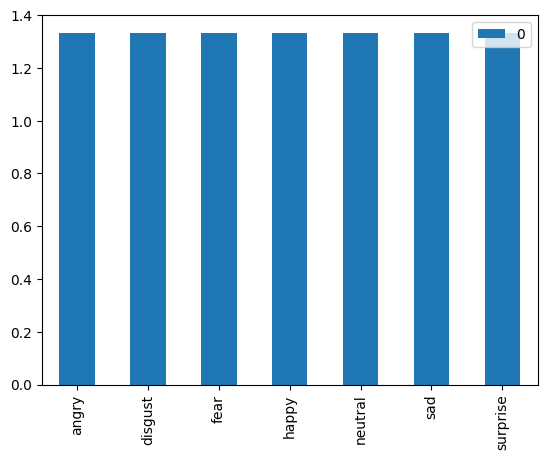

In [96]:
loss_df.T.sort_index().plot(kind="bar")

In [97]:
# Save the model (optional)
torch.save(model.state_dict(), "mnist_simple_nn.pth")

In [98]:
def export_onnx(model, onnx_path="dynamic_cnn.onnx"):
    dummy = torch.randn(1, 1, 256, 256)

    with torch.inference_mode():
        torch.onnx.export(
            model,
            dummy,
            onnx_path,
            opset_version=18,
            dynamo=False,
            export_params=True,
            do_constant_folding=True,
            input_names=["input"],
            output_names=["output"],
            dynamic_axes={
                "input": {0: "batch", 2: "height", 3: "width"},
                "output": {0: "batch"},
            },
        )

In [99]:
onnx_path = "model.onnx"
export_onnx(model, onnx_path)

C:\Users\nick\AppData\Local\Temp\ipykernel_11980\3476701642.py:5: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


SymbolicValueError: Unsupported: ONNX export of operator adaptive_avg_pool2d, input size not accessible. Please feel free to request support or submit a pull request on PyTorch GitHub: https://github.com/pytorch/pytorch/issues  [Caused by the value 'input.7 defined in (%input.7 : Float(*, 32, *, *, strides=[500000, 15625, 125, 1], requires_grad=0, device=cpu) = onnx::Relu(%23), scope: __main__.SimpleNN:: # D:\programming\python\2025-NN-AI\.venv\lib\site-packages\torch\nn\functional.py:1697:0
)' (type 'Tensor') in the TorchScript graph. The containing node has kind 'onnx::Relu'.] 
    (node defined in D:\programming\python\2025-NN-AI\.venv\lib\site-packages\torch\nn\functional.py(1697): relu
C:\Users\nick\AppData\Local\Temp\ipykernel_11980\1605122485.py(23): forward
D:\programming\python\2025-NN-AI\.venv\lib\site-packages\torch\nn\modules\module.py(1765): _slow_forward
D:\programming\python\2025-NN-AI\.venv\lib\site-packages\torch\nn\modules\module.py(1786): _call_impl
D:\programming\py

In [ ]:
import onnx

onnx_model = onnx.load(onnx_path)
onnx.checker.check_model(onnx_model)  # Check for model correctness

print("Model inputs:")
for input in onnx_model.graph.input:
    print(f"Input name: {input.name}")
    print(
        f"Input shape: {[(d.dim_value if d.HasField('dim_value') else d.dim_param) for d in input.type.tensor_type.shape.dim]}")

In [ ]:
# Take a look at model graph
# https://netron.app/